In [35]:
import pickle

# Moslin stuff
import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

# Plotting
import matplotlib.pyplot as plt
import pycea as py

# Single cell and LT
import scanpy as sc
from anndata import AnnData
import treedata as td

import numpy as np

In [36]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

#### Data and model Loading

In [37]:
# Open the file in read-binary mode
with open(output_data+"lp_two_days.pkl", 'rb') as file:
    lp = pickle.load(file)

# The 'data' variable now holds your reconstructed Python object
print(lp)


LineageProblem[(7.5, 8.0)]


In [38]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*R1.h5td"): # Taking only the first replicate

    #tdatas[file_path.stem] = td.read_h5td(file_path)

    # For testing, extract only timepoint lower than E9.0
    # Extract stage from filename (e.g., "E8.5-R1" from "E8.5-R1-C1.h5td")
    stem = file_path.stem
    stage = stem.split("-")[0]  # Extract "E8.5", "E9.0", etc.
    
    # Parse the stage to compare versions (e.g., E8.5, E9.0)
    stage_num = float(stage[1:])  # Remove 'E' and convert to float
    
    # Exclude E8.5 and above
    if stage_num < 8.5:
        tdatas[stem] = td.read_h5td(file_path)

In [47]:
for tdata in tdatas.values():
    print(tdata)

TreeData object with n_obs × n_vars = 1342 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'cell_type_colors', 'hvg', 'pca', 'pearson_residuals_normalization', 'stage_colors'
    obsm: 'X_scvi', 'X_umap', 'characters', 'X_pca'
    varm: 'PCs'
    obst: 'E7.5-R1-C1', 'E7.5-R1-C2'
TreeData object with n_obs × n_vars = 4498 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'cell_type_colors', 'hvg', 'pca', 'pearson_residuals_normaliz

#### Checking out the Umap 
 

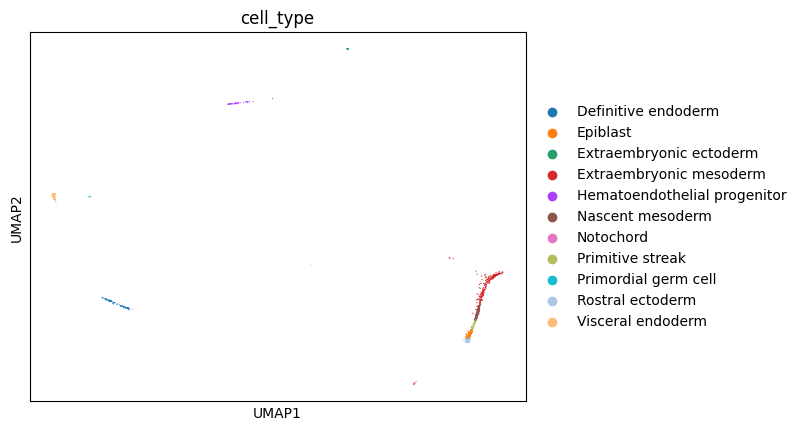

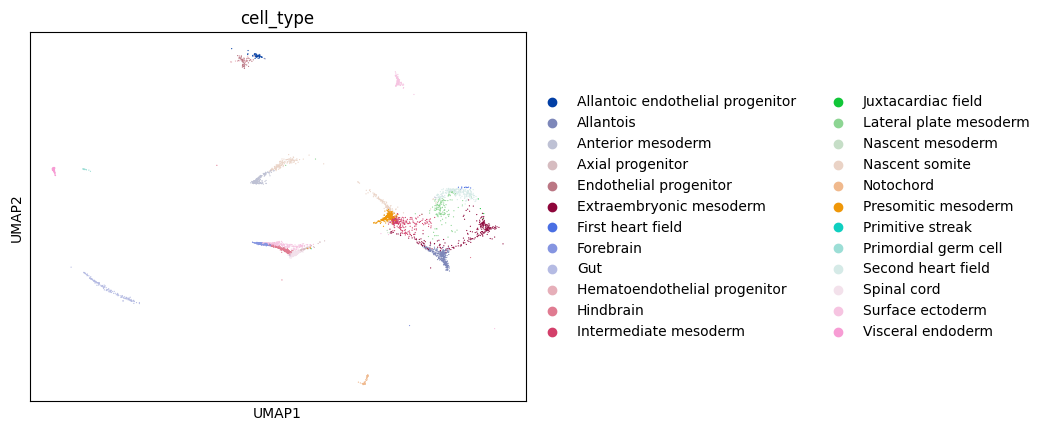

In [42]:
for tdata in tdatas.values():
    sc.pl.umap(tdata, color = 'cell_type', size=3)

#### Reclustering and Generate new Umap per time point

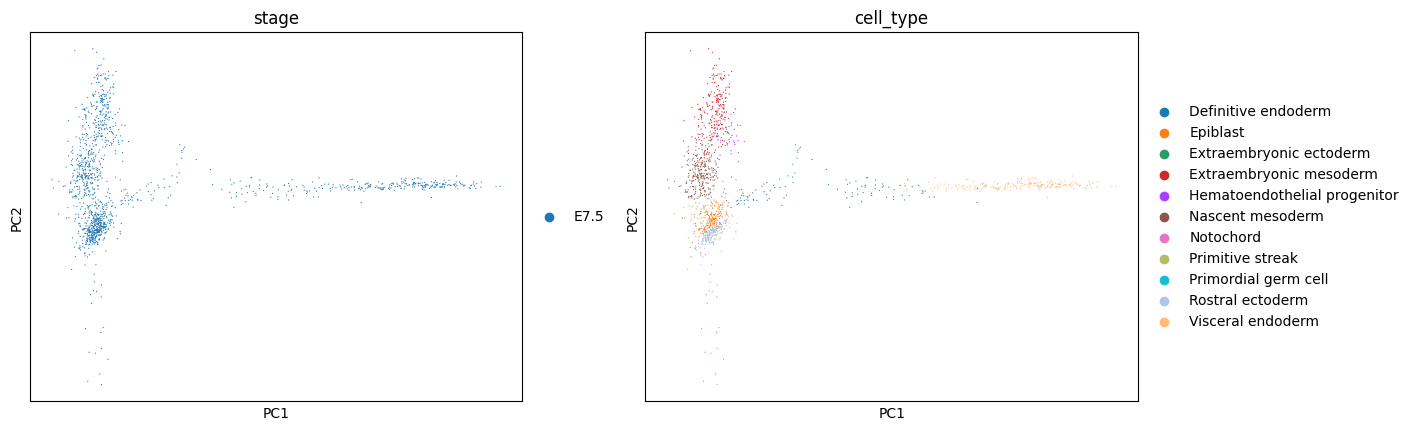

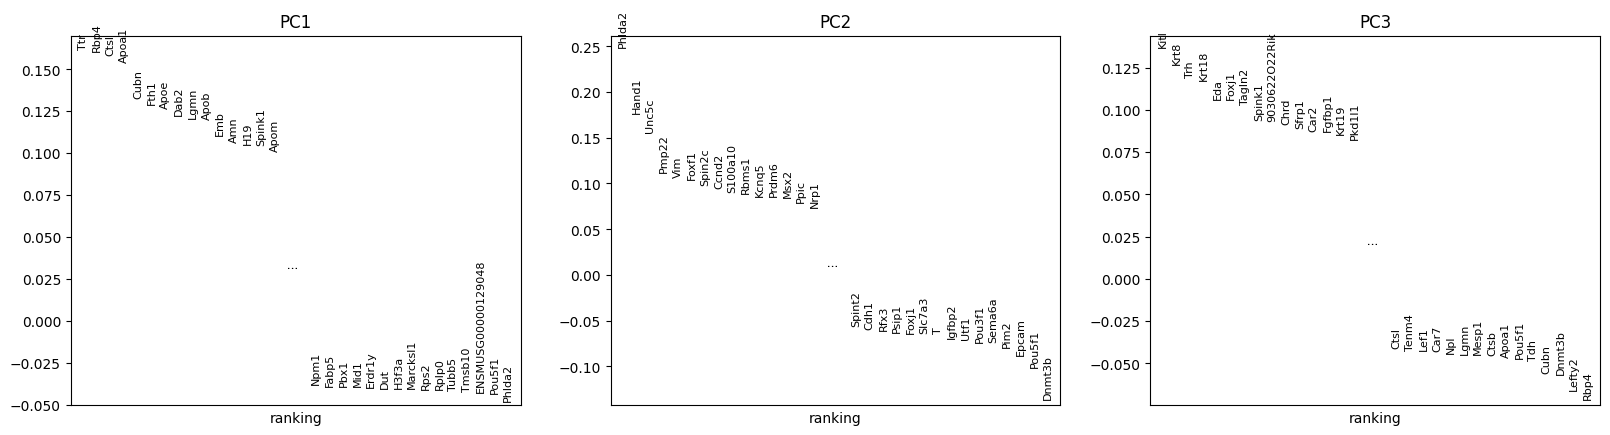

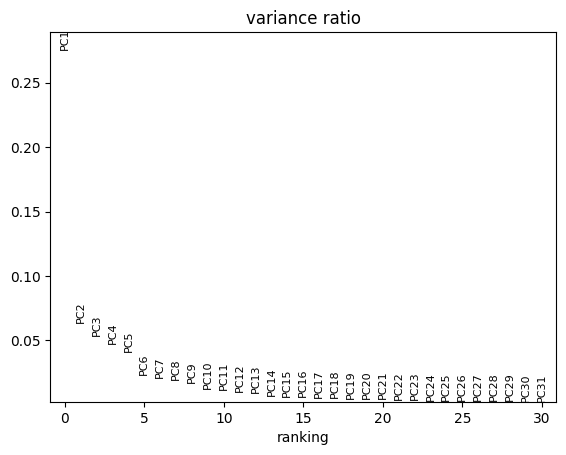

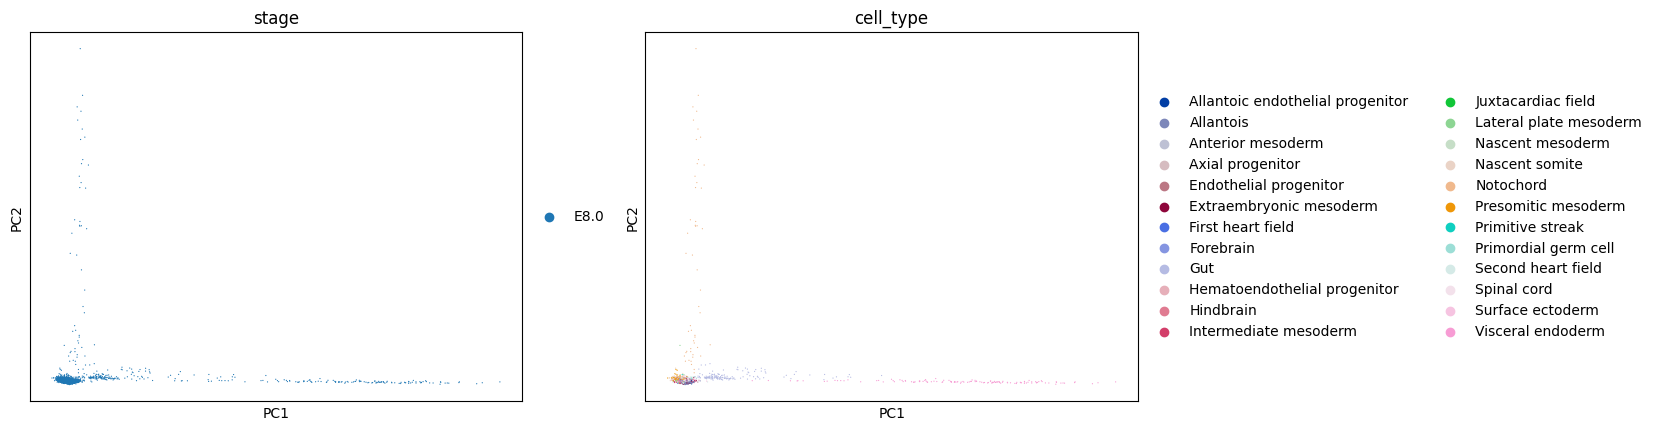

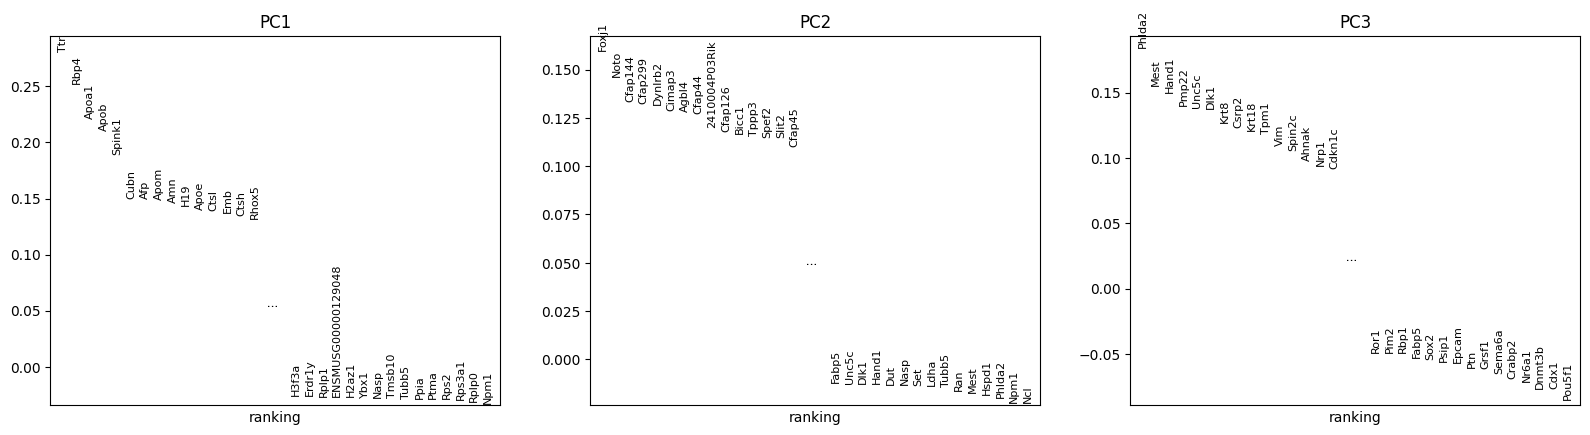

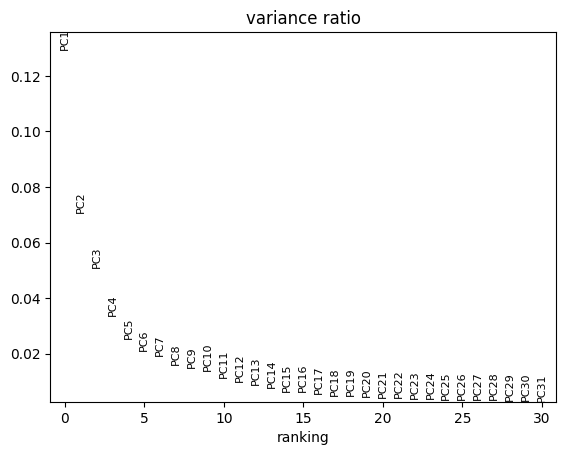

In [49]:
# Normalize and PCA
for tdata in tdatas.values():
    sc.experimental.pp.recipe_pearson_residuals(tdata, n_comps=50, n_top_genes=2000, chunksize=1000, clip=np.sqrt(tdata.n_obs))
    sc.pl.pca_overview(tdata, color = ["stage", "cell_type"],size = 3)


/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


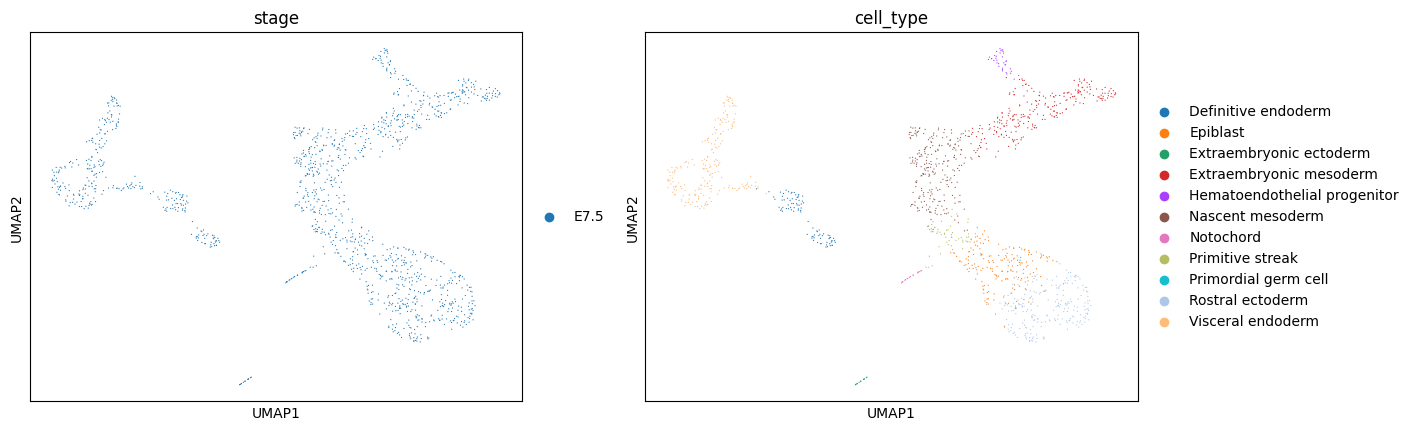

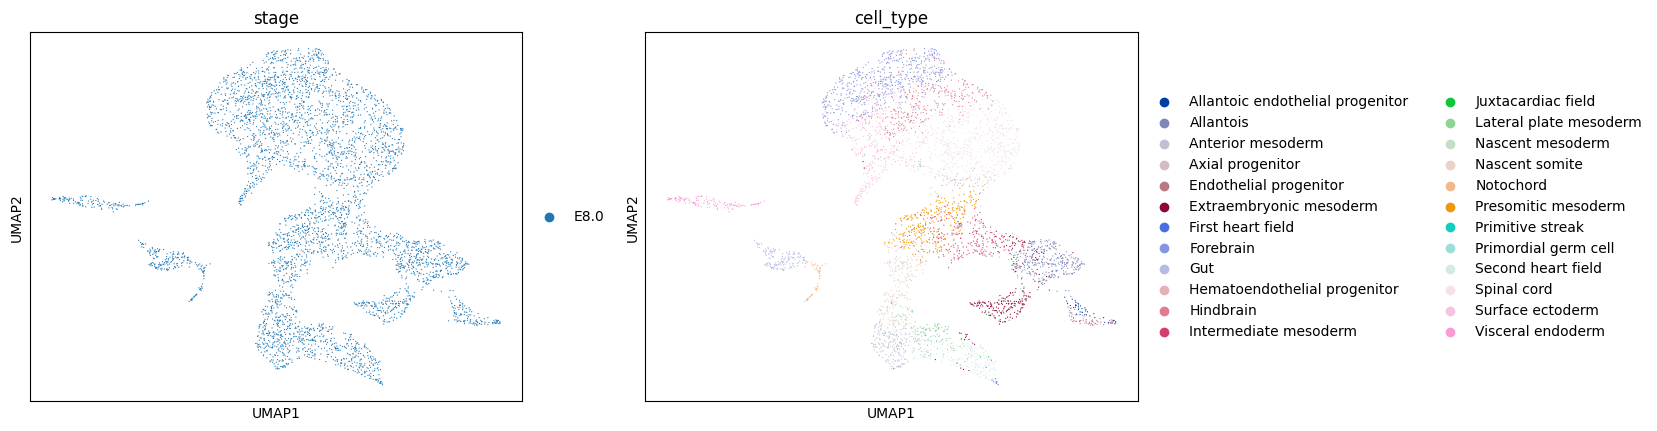

In [50]:
# Umap
for tdata in tdatas.values():
    sc.pp.neighbors(tdata, n_pcs=10)
    sc.tl.umap(tdata)
    sc.pl.umap(tdata, color =["stage", "cell_type"],size = 5)

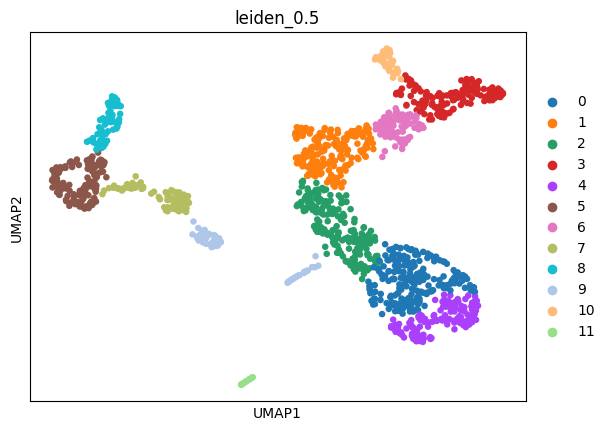

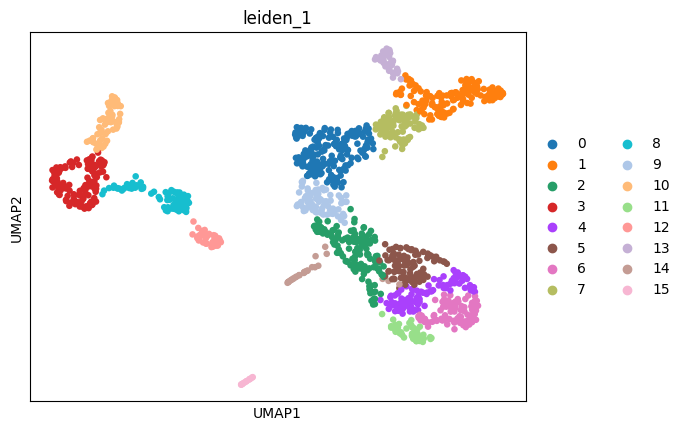

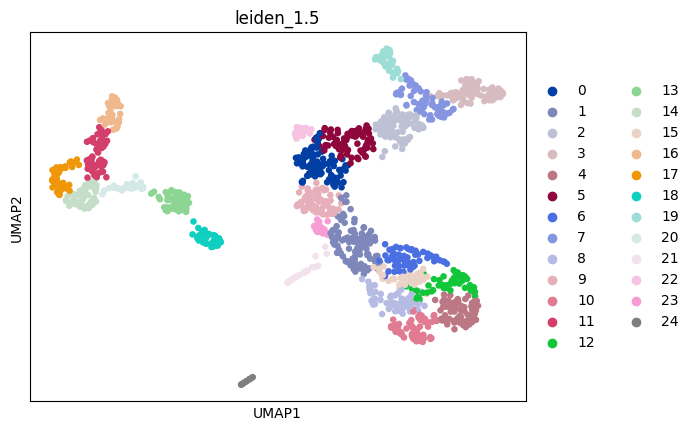

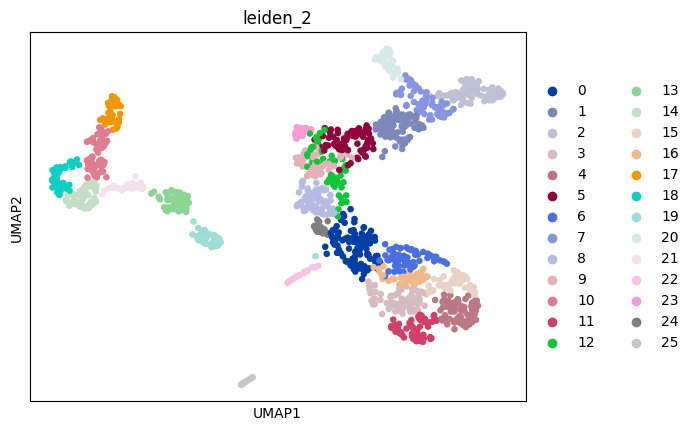

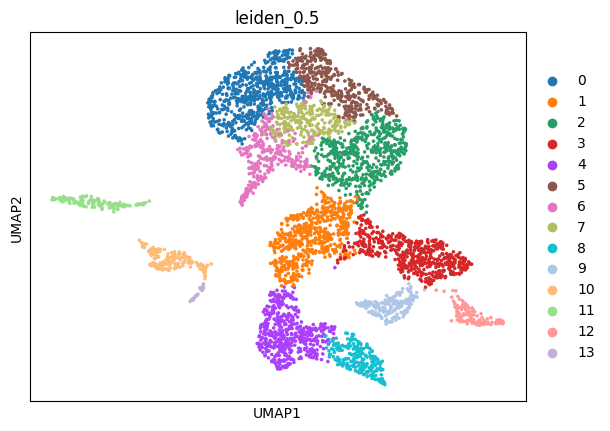

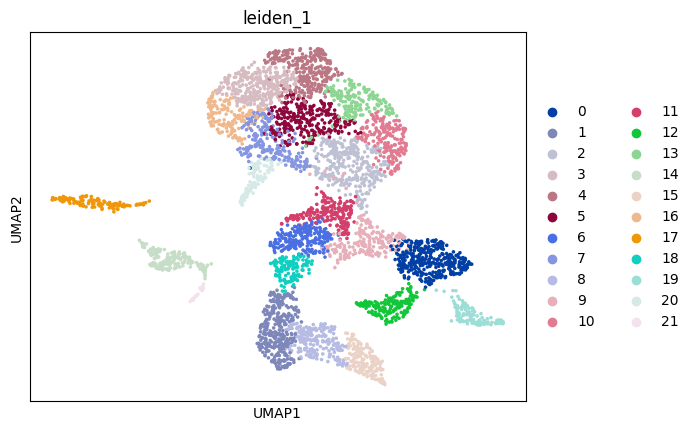

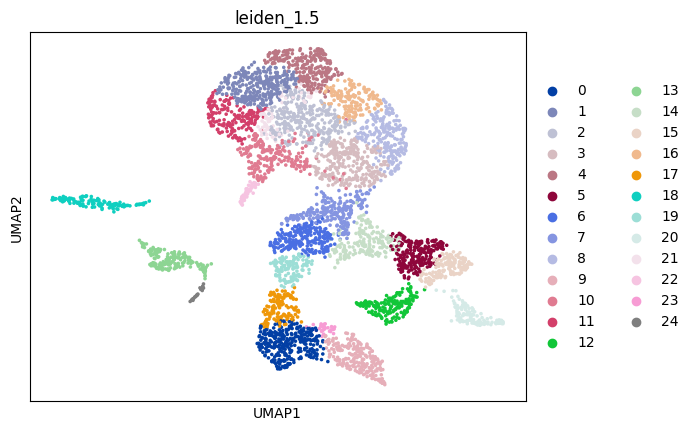

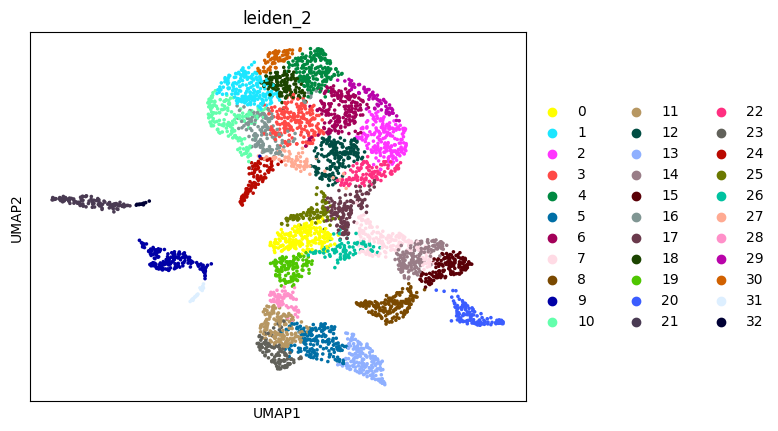

In [55]:
# Leiden Cluster
# Define resolutions
leiden_resolution = [0.5,1,1.5,2]
for tdata in tdatas.values():
    for i in leiden_resolution:
        sc.tl.leiden(tdata, resolution=i, key_added='leiden_'+str(i)) 
        sc.pl.umap(tdata, color='leiden_'+str(i))

#### Creating the "order" in the moslin TedSim tutorial. Leiden cluster both time points, and pass in the list of leiden clusters 

In [ ]:
early_state = 

TypeError: leiden() missing 1 required positional argument: 'adata'

In [88]:
lp.adata.obs['time']

E7.5-R1-T1-GGAGTTAGTTCGAGCC-1    7.5
E7.5-R1-T1-ACCGGATTCCGCAGAT-1    7.5
E7.5-R1-T1-TGCTAACGTTAGACGA-1    7.5
E7.5-R1-T1-AGTGTCATCCTTCAAC-1    7.5
E7.5-R1-T1-CTTCAGCCAAGGGATA-1    7.5
                                ... 
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1    8.0
E8.0-R1-T1-TGGTCCTCACTCGGAA-1    8.0
E8.0-R1-T1-TGTAGCGCAATCGAGT-1    8.0
E8.0-R1-T1-TGTCGATGTGCAATCT-1    8.0
E8.0-R1-T1-TGTCGTTTCGTGAGGA-1    8.0
Name: time, Length: 5840, dtype: category
Categories (2, float64): [7.5, 8.0]

#### Plotting transition heatmap and 

In [83]:
# To build the ordering programmatically rather than hardcoding:
source_types = lp.adata.obs.loc[lp.adata.obs["stage"] == "E7.5", "cell_type"].unique().tolist()
target_types = lp.adata.obs.loc[lp.adata.obs["stage"] == "E8.0", "cell_type"].unique().tolist()

# Shared types first (preserving source order), then types only in target appended at end
shared = [t for t in source_types if t in target_types]
target_only = [t for t in target_types if t not in source_types]
ordered_cell_type = shared + target_only

In [84]:
ordered_cell_type

['Extraembryonic mesoderm',
 'Nascent mesoderm',
 'Notochord',
 'Primitive streak',
 'Hematoendothelial progenitor',
 'Primordial germ cell',
 'Visceral endoderm',
 'Forebrain',
 'Hindbrain',
 'Spinal cord',
 'Surface ectoderm',
 'Axial progenitor',
 'Presomitic mesoderm',
 'Lateral plate mesoderm',
 'Nascent somite',
 'Anterior mesoderm',
 'Allantois',
 'Endothelial progenitor',
 'Gut',
 'Second heart field',
 'Intermediate mesoderm',
 'Juxtacardiac field',
 'First heart field',
 'Allantoic endothelial progenitor']

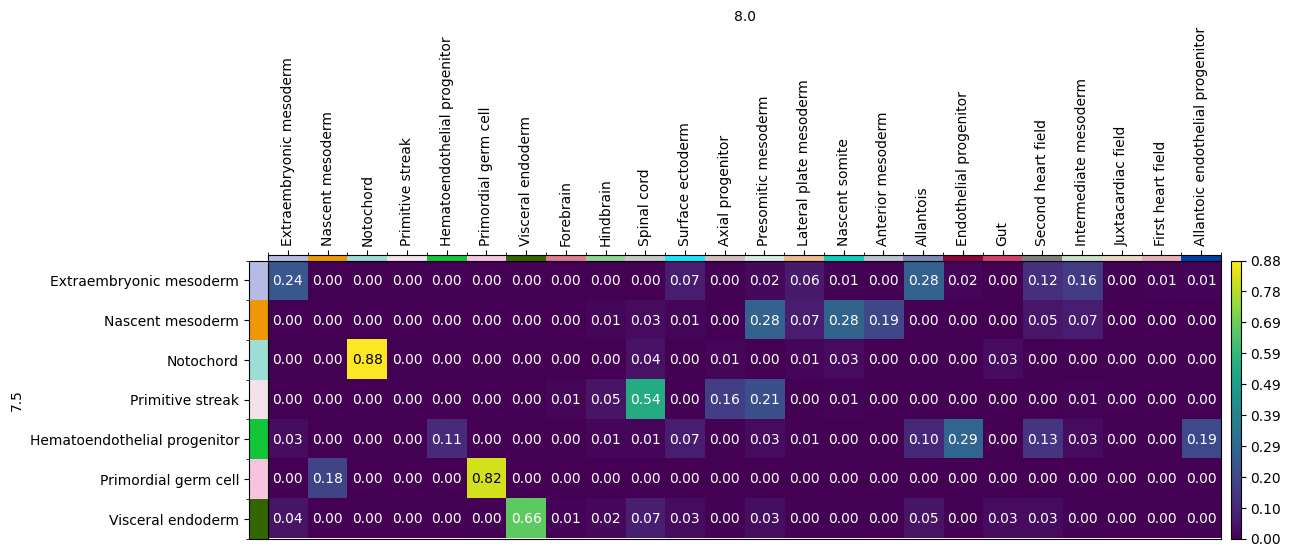

In [85]:
cell_transition = lp.cell_transition(
    source=7.5,
    target=8.0,
    source_groups= {"cell_type": ordered_cell_type},
    target_groups= {"cell_type": ordered_cell_type},
    forward=True,
   
)

mtp.cell_transition(lp, fontsize=10, figsize=(10, 10))

#### Plotting the Sankey plot

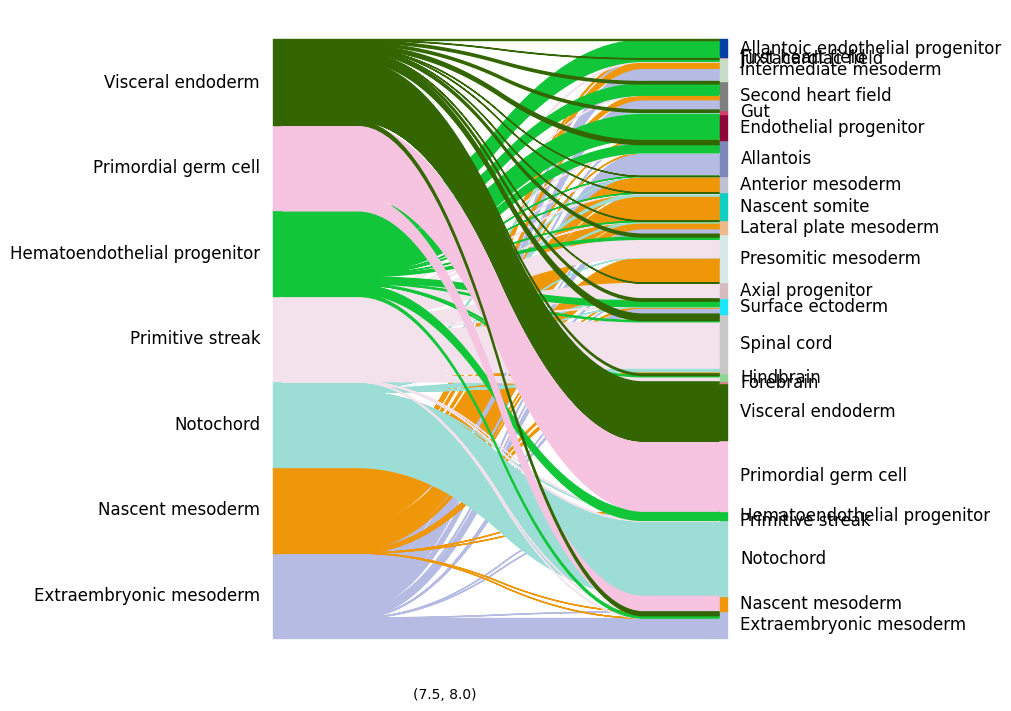

In [87]:
lp.sankey(
    source=7.5,
    target=8,
    source_groups= {"cell_type": ordered_cell_type},
    target_groups= {"cell_type": ordered_cell_type},
)
mtp.sankey(lp, figsize=(10, 7))